<a href="https://colab.research.google.com/github/SahilGaneshKarpate/Deploy-Your-Streamlit-Project-Using-GitHub-Streamlit-Cloud/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

uploaded = files.upload()

df = pd.read_csv("loan_approval_dataset.csv")

df.columns = df.columns.str.strip()

print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

print(df.columns)

print(df.dtypes)

Saving loan_approval_dataset.csv to loan_approval_dataset.csv
   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status 

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
0
Cleaning Completed


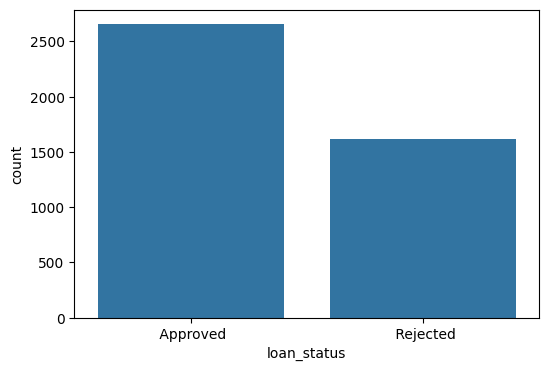

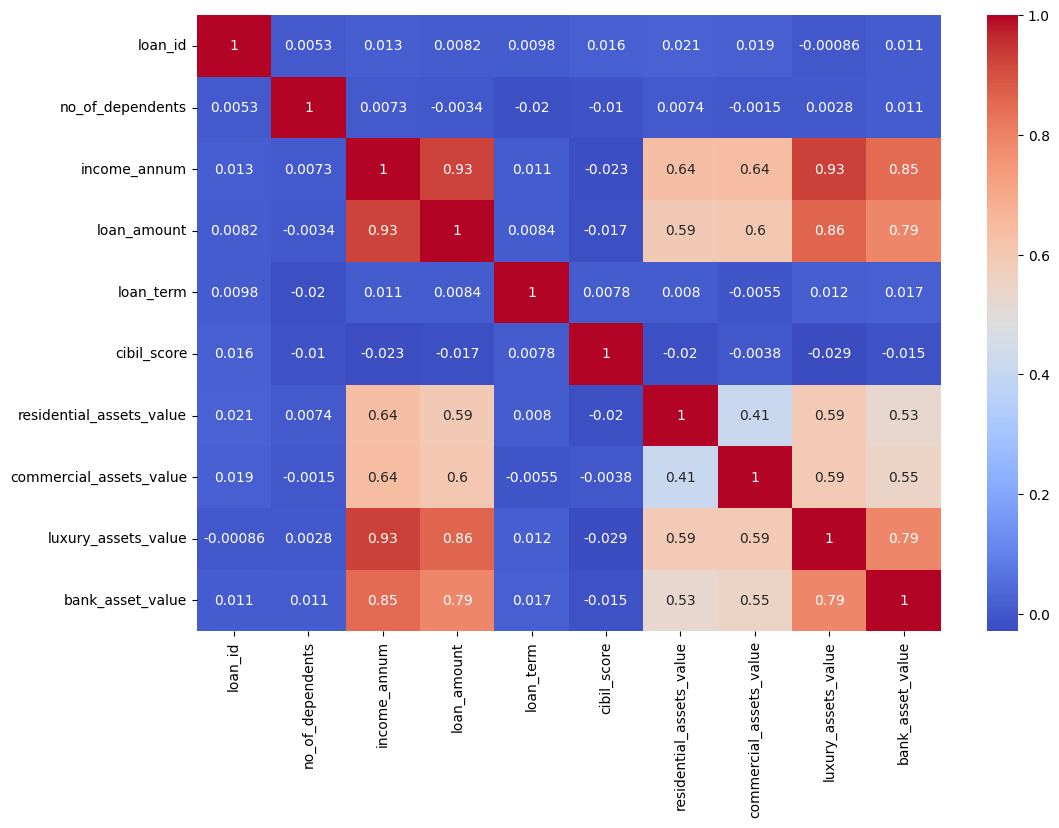

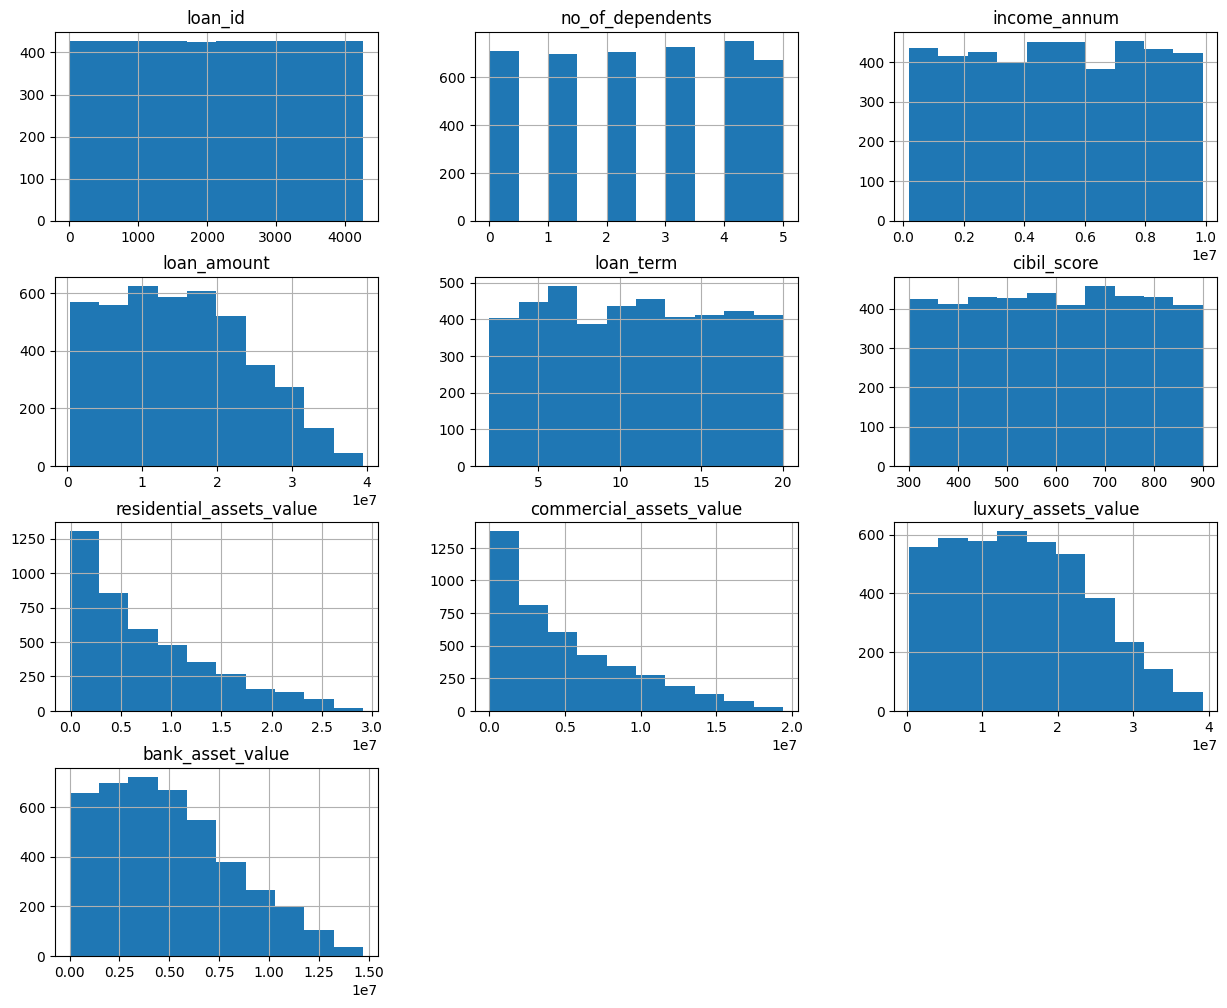

In [2]:
print(df.isnull().sum())

print(df.duplicated().sum())

df.columns = df.columns.str.strip()

df.drop_duplicates(inplace=True)

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=df[col].fillna(df[col].mode()[0])

    else:

        df[col]=df[col].fillna(df[col].median())

print("Cleaning Completed")

plt.figure(figsize=(6,4))
sns.countplot(x="loan_status",data=df)
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

df.hist(figsize=(15,12))
plt.show()

In [3]:
X = df.drop(["loan_id","loan_status"],axis=1)

y = df["loan_status"]

print(X.shape)

print(y.shape)

le=LabelEncoder()

for col in X.select_dtypes(include="object").columns:

    X[col]=le.fit_transform(X[col])

if y.dtype=="object":

    y=le.fit_transform(y)

print("Encoding Completed")

feature_columns=X.columns.tolist()

scaler=StandardScaler()

X=scaler.fit_transform(X)

print("Scaling Completed")

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

model=LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

print("Model Trained")

y_pred=model.predict(X_test)

print(y_pred[:10])

(4269, 11)
(4269,)
Encoding Completed
Scaling Completed
(3415, 11)
(854, 11)
Model Trained
[0 0 0 0 0 1 0 0 0 0]


0.9227166276346604
0.9158576051779935
0.8761609907120743
0.8955696202531646
[[505  26]
 [ 40 283]]


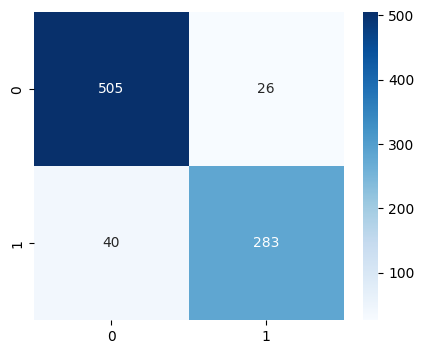

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       531
           1       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854

Model Saved
Scaler Saved
Columns Saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PROJECT COMPLETED SUCCESSFULLY
Accuracy : 0.9227166276346604
Precision : 0.9158576051779935
Recall : 0.8761609907120743
F1 Score : 0.8955696202531646
Generated Files
loan_approval_model.pkl
scaler.pkl
columns.pkl


In [4]:
accuracy=accuracy_score(y_test,y_pred)

print(accuracy)

precision=precision_score(y_test,y_pred)

print(precision)

recall=recall_score(y_test,y_pred)

print(recall)

f1=f1_score(y_test,y_pred)

print(f1)

cm=confusion_matrix(y_test,y_pred)

print(cm)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.show()

print(classification_report(y_test,y_pred))

joblib.dump(model,"loan_approval_model.pkl")

print("Model Saved")

joblib.dump(scaler,"scaler.pkl")

print("Scaler Saved")

joblib.dump(feature_columns,"columns.pkl")

print("Columns Saved")

files.download("loan_approval_model.pkl")

files.download("scaler.pkl")

files.download("columns.pkl")

print("="*50)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*50)

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 Score :",f1)

print("Generated Files")

print("loan_approval_model.pkl")

print("scaler.pkl")

print("columns.pkl")